Imports & Setup


In [1]:
# Import required libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


Load Data & Inspect Structure

In [2]:
# Read dataset into DataFrame
df = pd.read_csv('eda_manipulate_date_strings_with_python.csv')

# Display first 5 rows
df.head(5)

,date,number_of_strikes,center_point_geom
0,2016-01-01,870,POINT(-89.4 48.6)
1,2016-01-01,3782,POINT(-115.1 42.9)
2,2016-01-01,3102,POINT(-117.6 38.8)
3,2016-01-01,476,POINT(-66.2 45.4)
4,2016-01-01,4436,POINT(-101.4 28.7)


Convert Date Column & Extract Time Features

In [3]:
# 1. Convert the 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Extract date components (including year)
df['week'] = df['date'].dt.strftime('%Y-W%V')
df['month'] = df['date'].dt.strftime('%Y-%m')
df['quarter'] = df['date'].dt.to_period('Q').dt.strftime('%Y-Q%q')
df['year'] = df['date'].dt.strftime('%Y')
# 3. Check the dataframe structure
df.head()

,date,number_of_strikes,center_point_geom,week,month,quarter,year
0,2016-01-01,870,POINT(-89.4 48.6),2016-W53,2016-01,2016-Q1,2016
1,2016-01-01,3782,POINT(-115.1 42.9),2016-W53,2016-01,2016-Q1,2016
2,2016-01-01,3102,POINT(-117.6 38.8),2016-W53,2016-01,2016-Q1,2016
3,2016-01-01,476,POINT(-66.2 45.4),2016-W53,2016-01,2016-Q1,2016
4,2016-01-01,4436,POINT(-101.4 28.7),2016-W53,2016-01,2016-Q1,2016


Aggregate Weekly Data for 2018 & Plot

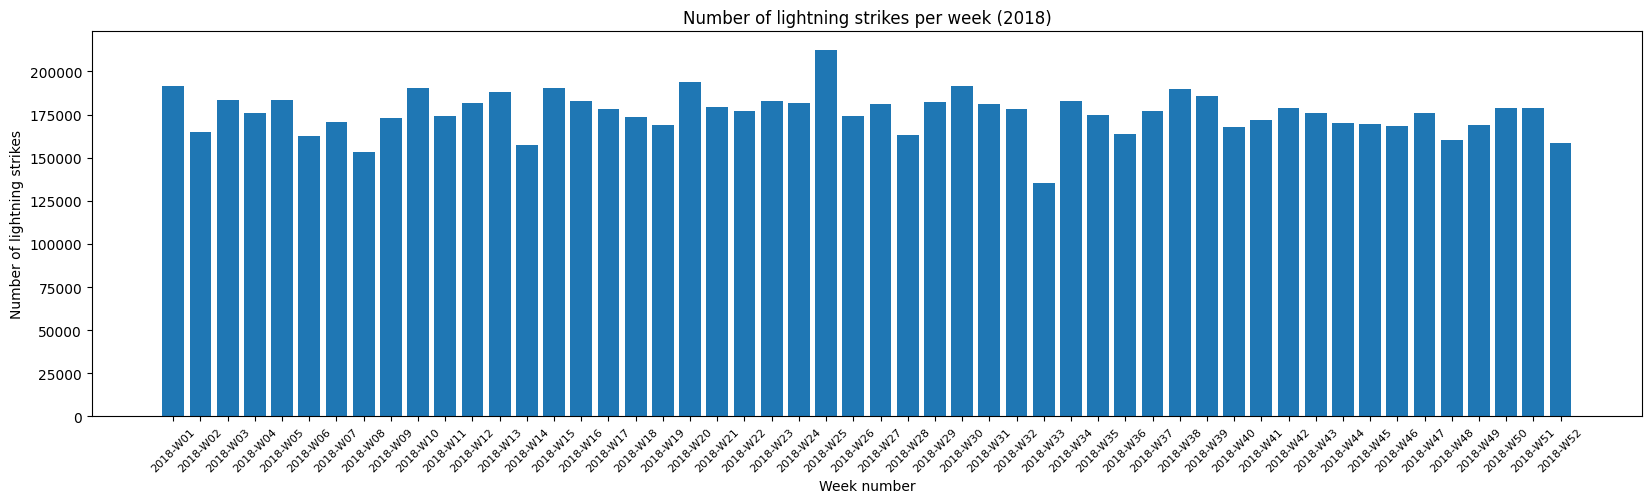

In [4]:
# Filter for 2018 data and group by week
# Note: numeric_only=True is required in pandas 2.0+ when non-numeric columns exist
df_by_week_2018 = df[df['year'] == '2018'].groupby(['week'])['number_of_strikes'].sum().reset_index()

# Plot bar graph with rotated labels
plt.figure(figsize=(20, 5))
plt.bar(x=df_by_week_2018['week'], height=df_by_week_2018['number_of_strikes'])
plt.xlabel("Week number")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes per week (2018)")
plt.xticks(rotation=45, fontsize=8)
plt.show()

Quarterly Total Calculations & Formatting

In [5]:
df_by_quarter = df.groupby(['quarter'])['number_of_strikes'].sum().reset_index()
# format strike values in millions(eg.,2.7M)
df_by_quarter['number_of_strikes_formatted'] = (df_by_quarter['number_of_strikes'].div(1000000).round(1).astype(str)+ 'M')
df_by_quarter.head()

,quarter,number_of_strikes,number_of_strikes_formatted
0,2016-Q1,2342926,2.3M
1,2016-Q2,2280899,2.3M
2,2016-Q3,2253443,2.3M
3,2016-Q4,2392375,2.4M
4,2017-Q1,2274787,2.3M


Bar Graph of Quarterly Totals with Custom Annotations

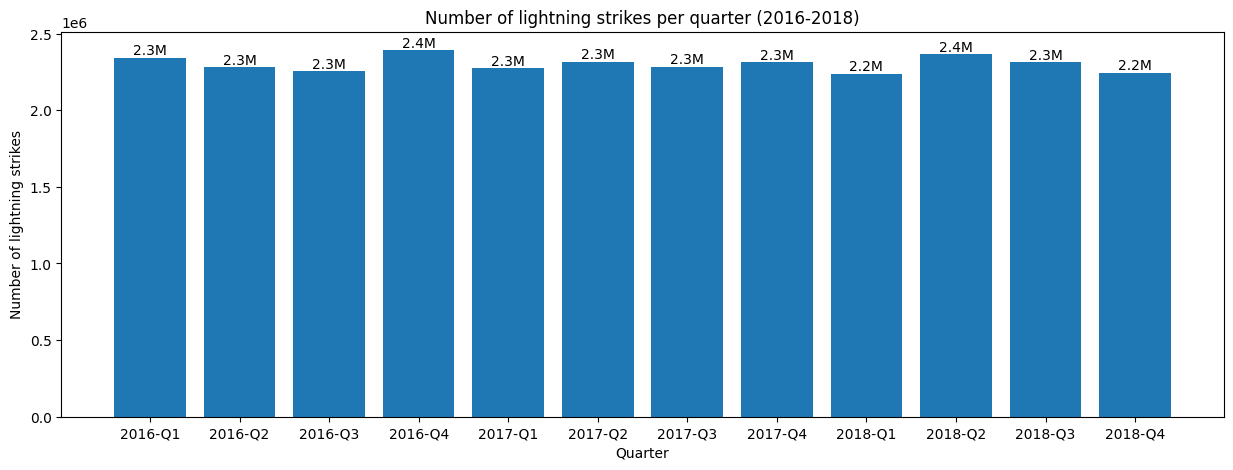

In [6]:
def addlabels(x,y, labels):
  for i in range(len(x)):
    plt.text(i,y[i], labels[i], ha='center', va='bottom')
plt.figure(figsize=(15,5))
plt.bar(x=df_by_quarter['quarter'], height=df_by_quarter['number_of_strikes'])
addlabels(df_by_quarter['quarter'], df_by_quarter["number_of_strikes"], df_by_quarter['number_of_strikes_formatted'])
plt.xlabel("Quarter")
plt.ylabel('Number of lightning strikes')
plt.title('Number of lightning strikes per quarter (2016-2018)')
plt.show()

Grouped Bar Chart by Quarter & Year (Seaborn)

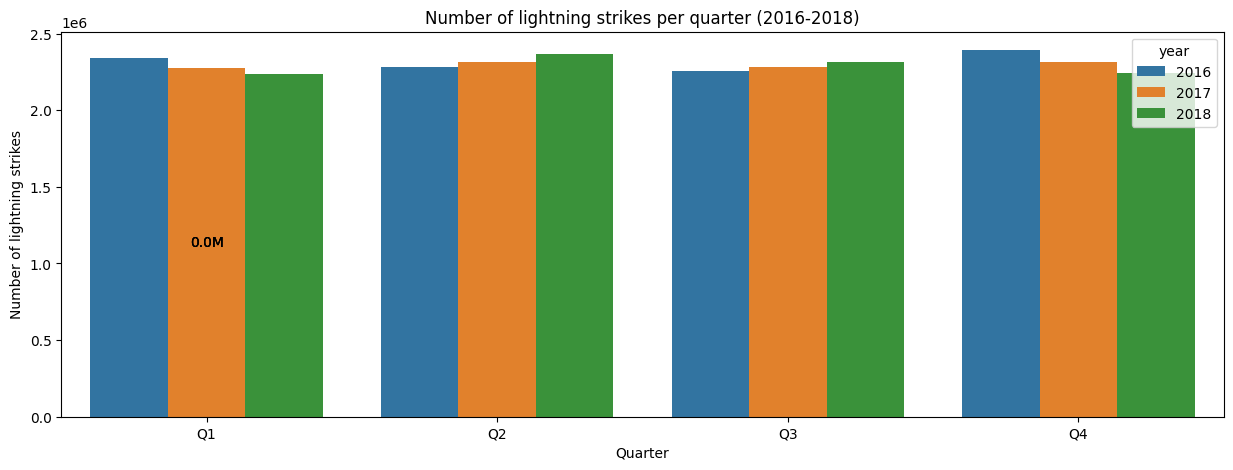

In [7]:
# Extract quarter number and year for comparison
df_by_quarter['quarter_number'] = df_by_quarter['quarter'].str[-2:]
df_by_quarter['year'] = df_by_quarter['quarter'].str[:4]

# Create grouped bar plot using Seaborn
plt.figure(figsize=(15, 5))
p = sns.barplot(
    data=df_by_quarter,
    x='quarter_number',
    y='number_of_strikes',
    hue='year'
)

# Annotate each bar with value in millions
for b in p.patches:
    p.annotate(
        f"{round(b.get_height() / 1e6, 1)}M",
        (b.get_x() + b.get_width() / 2., b.get_height() + 1.2e6),
        ha='center', va='bottom',
        xytext=(0, -12),
        textcoords='offset points'
    )

plt.xlabel("Quarter")
plt.ylabel("Number of lightning strikes")
plt.title("Number of lightning strikes per quarter (2016-2018)")
plt.show()